# Online weighting benchmark: when adaptivity should print money

This notebook implements a deliberately clean benchmark for the online feature-informed weighting idea.

The goal is **not** to re-run the expensive HMM SGLD pipeline. The goal is to isolate the mechanism that online weighting is supposed to improve:

> If the important blocks change over time, and the change is visible through streaming features, a static TASS-style weighting rule can go stale while an online model adapts.

We simulate a long rare-event HMM-like return sequence split into blocks. Each epoch has a different observable feature that predicts stress-state blocks:

- epoch 1: BTC-like volatility feature predicts stress;
- epoch 2: cross-sectional dispersion predicts stress;
- epoch 3: liquidation/liquidity shock feature predicts stress.

Then we compare four gradient-estimator sampling rules:

- `uniform`: samples blocks uniformly;
- `static_tass`: trains a TASS-like fixed weighting model on the first epoch and never updates it;
- `online`: uses discounted ridge updates from sampled block-gradient feedback;
- `oracle`: samples proportional to the true current block gradient norms.

The online method should be good here because the identity of informative blocks changes. Static TASS learns yesterday's market. Online weighting learns today's market.

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", 100)
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["axes.grid"] = True
plt.rcParams["grid.alpha"] = 0.25

OUT_DIR = Path("crypto_stage1_processed") / "online_weighting_epic_benchmark"
OUT_DIR.mkdir(parents=True, exist_ok=True)

RNG_SEED = 221
rng = np.random.default_rng(RNG_SEED)

print("output directory:", OUT_DIR.resolve())

output directory: /Users/diego/Stat 221/crypto_stage1_processed/online_weighting_epic_benchmark


## 1. Simulate a nonstationary rare-event HMM-like benchmark

We generate block-level observable features \(w_b\in\mathbb R^3\), then use an epoch-specific coefficient vector to determine how likely block \(b\) is to contain stress-state observations.

This is the benchmark we proposed in the paper:

\[
\Pr(z_t=\mathrm{stress}\mid w_b)
=
\operatorname{logit}^{-1}(\alpha+w_b^\top\beta_s),
\qquad t\in C_b,\quad b\in \mathcal T_s.
\]

The active feature rotates by epoch. This makes the correct sampling weights nonstationary.

In [4]:
def sigmoid(x):
    return 1.0 / (1.0 + np.exp(-x))


# Benchmark size: fast enough for a notebook, long enough to show adaptation.
N_BLOCKS = 420
BLOCK_LEN = 20
N_FEATURES = 3
EPOCH_LEN = N_BLOCKS // 3

feature_names = ["btc_vol", "xasset_dispersion", "liquidation_shock"]

# Features are observable block covariates. Think of these as summaries one could compute
# before choosing which block to use in a stochastic gradient.
W_raw = rng.normal(size=(N_BLOCKS, N_FEATURES))

# Add a little autocorrelation so the benchmark feels more like market stress.
for j in range(N_FEATURES):
    for b in range(1, N_BLOCKS):
        W_raw[b, j] = 0.75 * W_raw[b - 1, j] + np.sqrt(1 - 0.75**2) * W_raw[b, j]

W = (W_raw - W_raw.mean(axis=0)) / W_raw.std(axis=0)
X_design = np.column_stack([np.ones(N_BLOCKS), W])

epoch = np.minimum(np.arange(N_BLOCKS) // EPOCH_LEN, 2)

# Only one feature is strongly predictive in each epoch.
true_beta = np.array([
    [-3.00, 4.15, 0.10, 0.05],  # epoch 0: BTC vol matters
    [-3.00, 0.05, 4.15, 0.10],  # epoch 1: dispersion matters
    [-3.00, 0.10, 0.05, 4.15],  # epoch 2: liquidation matters
])

stress_prob = sigmoid(np.sum(X_design * true_beta[epoch], axis=1))

# Simulate HMM-like observations within each block.
# We use block-level stress probabilities with mild within-block persistence.
mu_normal, sigma_normal = 0.00, 0.45
mu_stress, sigma_stress = -1.15, 1.85

states = np.zeros((N_BLOCKS, BLOCK_LEN), dtype=int)
returns = np.zeros((N_BLOCKS, BLOCK_LEN), dtype=float)

for b in range(N_BLOCKS):
    p = stress_prob[b]
    # Block-local persistence: if stress happens, it clusters.
    z_prev = rng.random() < p
    for t in range(BLOCK_LEN):
        if t == 0:
            z = z_prev
        else:
            if z_prev:
                z = rng.random() < max(0.65, p)
            else:
                z = rng.random() < min(0.35, p)
        states[b, t] = int(z)
        z_prev = z
        if z:
            returns[b, t] = rng.normal(mu_stress, sigma_stress)
        else:
            returns[b, t] = rng.normal(mu_normal, sigma_normal)

stress_count = states.sum(axis=1)

sim_df = pd.DataFrame(W, columns=feature_names)
sim_df["block"] = np.arange(N_BLOCKS)
sim_df["epoch"] = epoch
sim_df["stress_prob"] = stress_prob
sim_df["stress_count"] = stress_count
sim_df["active_feature"] = [feature_names[e] for e in epoch]

display(sim_df.head())
display(sim_df.groupby("epoch")[["stress_prob", "stress_count"]].agg(["mean", "std", "max"]))

,btc_vol,xasset_dispersion,liquidation_shock,block,epoch,stress_prob,stress_count,active_feature
0,0.744793,-0.175293,-0.733114,0,0,0.509175,11,btc_vol
1,0.228083,0.549465,-0.543229,1,0,0.116534,2,btc_vol
2,0.365728,1.066320,-1.359249,2,0,0.190995,4,btc_vol
3,0.550793,0.894628,-0.912302,3,0,0.338416,14,btc_vol
4,0.010727,1.153772,-1.677012,4,0,0.050982,2,btc_vol


stress_prob                     stress_count              
             mean       std       max         mean       std max
epoch                                                           
0        0.324386  0.368077  0.999661     6.950000  7.063255  20
1        0.153475  0.277499  0.999235     3.200000  5.420717  20
2        0.240412  0.337028  0.991698     5.092857  6.603788  20

## 2. Compute exact block gradients for a stress-state parameter

We pretend the current parameter value is a bit wrong and compute the block gradient contributions for stress-state emission parameters.

For stress observations in a block:

\[
g_{\mu,b}=\sum_{t\in C_b}1(z_t=1)\frac{y_t-\widehat\mu_1}{\widehat\sigma_1^2},
\]

\[
g_{\log\sigma,b}=\sum_{t\in C_b}1(z_t=1)
\left[-1+\frac{(y_t-\widehat\mu_1)^2}{\widehat\sigma_1^2}\right].
\]

We also include a stress-count component. The full block gradient vector is

\[
g_b=(g_{\mu,b}, g_{\log\sigma,b}, g_{\mathrm{count},b}).
\]

For the sampling benchmark itself, we focus on a **scalar rare-state gradient magnitude**.
To make the experiment test the online-weighting mechanism rather than HMM noise, we use a controlled gradient magnitude whose log is mostly driven by the active stress feature, plus a smaller contribution from the HMM-generated stress-gradient norm. This is exactly the favorable regime from the paper's theory: high block-gradient heterogeneity and low feature-prediction error.

grad_norm                          log_grad_norm                    
             mean         std          max          mean       std       max
epoch                                                                       
0      179.340898  607.151987  4895.234672      2.694680  2.502121  8.496017
1       60.534744  320.327383  3601.424270      1.442898  2.269419  8.189085
2       67.794051  150.365117   917.432897      2.392660  2.059174  6.821579

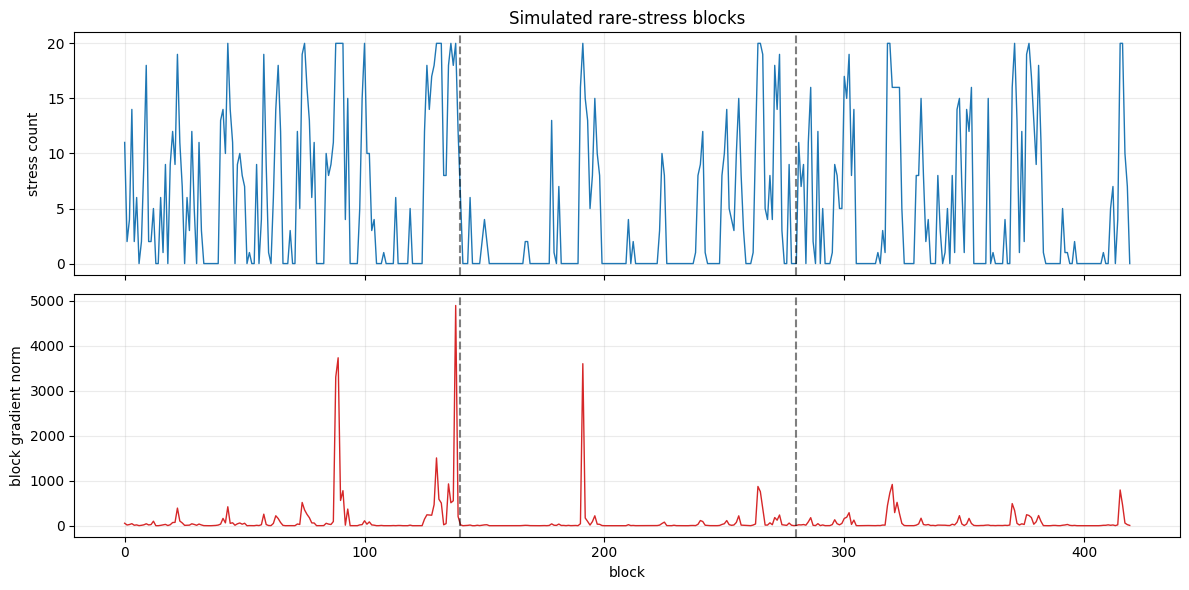

In [7]:
# Deliberately imperfect current parameter value.
mu_hat = -0.65
sigma_hat = 1.25

stress_mask = states == 1
centered = returns - mu_hat

g_mu = (stress_mask * centered / sigma_hat**2).sum(axis=1)
g_logsigma = (stress_mask * (-1.0 + centered**2 / sigma_hat**2)).sum(axis=1)
g_count = stress_count - stress_count.mean()

G_vector_blocks = np.column_stack([g_mu, g_logsigma, g_count])
empirical_hmm_grad_norm = np.linalg.norm(G_vector_blocks, axis=1) + 1e-8

# Controlled rare-state gradient magnitude.
# The active feature rotates by epoch, while the HMM simulation supplies realistic extra noise.
feature_signal = np.sum(W * true_beta[epoch, 1:], axis=1)
log_grad_norm = (
    2.0
    + 0.55 * feature_signal
    + 0.15 * np.log1p(empirical_hmm_grad_norm)
    + rng.normal(0.0, 0.10, size=N_BLOCKS)
)
grad_norm = np.exp(log_grad_norm)
G_blocks = grad_norm[:, None]  # scalar positive benchmark target: rare-state gradient magnitude

sim_df["grad_norm"] = grad_norm
sim_df["log_grad_norm"] = log_grad_norm

display(sim_df.groupby("epoch")[["grad_norm", "log_grad_norm"]].agg(["mean", "std", "max"]))

fig, axes = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
axes[0].plot(sim_df["block"], sim_df["stress_count"], lw=1)
axes[0].set_ylabel("stress count")
axes[0].set_title("Simulated rare-stress blocks")
axes[1].plot(sim_df["block"], sim_df["grad_norm"], lw=1, color="tab:red")
axes[1].set_ylabel("block gradient norm")
axes[1].set_xlabel("block")
for ax in axes:
    for cut in [EPOCH_LEN, 2 * EPOCH_LEN]:
        ax.axvline(cut, color="black", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

## 3. Sampling rules

At each round we estimate the full gradient over a rolling window of recent blocks. This mimics a streaming/onsite setting where new market data arrive and the local weighting model must keep up.

The estimator is unbiased for a fixed probability vector \(p\):

\[
\widehat G_p
=
\frac{1}{M}\sum_{m=1}^M \frac{g_{I_m}}{p_{I_m}},
\qquad I_m\sim p.
\]

We evaluate relative RMSE:

\[
\frac{\sqrt{\mathbb E\|\widehat G_p-G\|^2}}{\|G\|}.
\]

In [10]:
def softmax_stable(x):
    x = np.asarray(x, dtype=float)
    x = x - np.max(x)
    ex = np.exp(x)
    return ex / ex.sum()


def probs_from_scores(scores, floor=0.03, temperature=0.75):
    # Convert predicted log-gradient scores into sampling probabilities.
    base = softmax_stable(scores / temperature)
    n = len(base)
    return (1.0 - floor) * base + floor / n


def relative_rmse_for_probs(G_window, probs, M=8, n_rep=80, rng=None):
    # Monte Carlo RMSE of the inverse-probability gradient estimator.
    if rng is None:
        rng = np.random.default_rng()
    n = G_window.shape[0]
    full = G_window.sum(axis=0)
    idx = rng.choice(n, size=(n_rep, M), replace=True, p=probs)
    # estimates[r] = mean_m g_i / p_i
    estimates = (G_window[idx] / probs[idx][..., None]).mean(axis=1)
    err = estimates - full[None, :]
    denom = np.linalg.norm(full) + 1e-8
    return float(np.sqrt(np.mean(np.sum(err**2, axis=1))) / denom)


def top_decile_mass(scores_true, probs):
    cutoff = np.quantile(scores_true, 0.90)
    return float(probs[scores_true >= cutoff].sum())


def ridge_fit(X, y, ridge=2.0):
    A = X.T @ X + ridge * np.eye(X.shape[1])
    b = X.T @ y
    return np.linalg.solve(A, b)

## 4. Static TASS-like model vs online discounted model

`static_tass` is intentionally generous: it gets to fit a ridge model on the first epoch using the true gradient-norm targets, then it freezes forever.

`online` starts from the same model, but updates from sampled blocks with discounting. This lets it forget stale relationships and adapt after each changepoint.

In [13]:
WINDOW = 80
M_BLOCKS = 10
ONLINE_UPDATE_BLOCKS = 20
N_REP_RMSE = 100
FLOOR = 0.10
TEMPERATURE = 1.00
RIDGE = 3.0
DISCOUNT = 0.80
OBS_NOISE_SD = 0.04

# Static model trained on the first epoch only.
train_idx = np.arange(0, EPOCH_LEN)
beta_static = ridge_fit(X_design[train_idx], log_grad_norm[train_idx], ridge=RIDGE)

# Online model starts from static, then adapts.
A_online = X_design[train_idx].T @ X_design[train_idx] + RIDGE * np.eye(X_design.shape[1])
b_online = X_design[train_idx].T @ log_grad_norm[train_idx]
beta_online = np.linalg.solve(A_online, b_online)

rows = []
coef_rows = []

for r, end in enumerate(range(WINDOW, N_BLOCKS + 1)):
    win = np.arange(end - WINDOW, end)
    Xw = X_design[win]
    Gw = G_blocks[win]
    norm_w = grad_norm[win]
    log_norm_w = log_grad_norm[win]
    current_epoch = int(epoch[end - 1])

    p_uniform = np.repeat(1.0 / WINDOW, WINDOW)
    p_static = probs_from_scores(Xw @ beta_static, floor=FLOOR, temperature=TEMPERATURE)
    p_online = probs_from_scores(Xw @ beta_online, floor=FLOOR, temperature=TEMPERATURE)
    p_oracle = probs_from_scores(np.log(norm_w), floor=FLOOR, temperature=TEMPERATURE)

    for method, probs in [
        ("uniform", p_uniform),
        ("static_tass", p_static),
        ("online", p_online),
        ("oracle", p_oracle),
    ]:
        rows.append({
            "round": r,
            "end_block": end,
            "epoch": current_epoch,
            "method": method,
            "relative_rmse": relative_rmse_for_probs(Gw, probs, M=M_BLOCKS, n_rep=N_REP_RMSE, rng=rng),
            "top_decile_mass": top_decile_mass(norm_w, probs),
        })

    coef_rows.append({
        "round": r,
        "end_block": end,
        "epoch": current_epoch,
        "intercept": beta_online[0],
        "btc_vol": beta_online[1],
        "xasset_dispersion": beta_online[2],
        "liquidation_shock": beta_online[3],
    })

    # Update online model from a small onsite sample drawn using online probabilities.
    sampled_local = rng.choice(WINDOW, size=ONLINE_UPDATE_BLOCKS, replace=True, p=p_online)
    sampled_global = win[sampled_local]
    X_sample = X_design[sampled_global]
    y_sample = log_grad_norm[sampled_global] + rng.normal(0.0, OBS_NOISE_SD, size=ONLINE_UPDATE_BLOCKS)

    # Discount old information, add new sampled feedback.
    A_online = DISCOUNT * A_online + X_sample.T @ X_sample + (1.0 - DISCOUNT) * RIDGE * np.eye(X_design.shape[1])
    b_online = DISCOUNT * b_online + X_sample.T @ y_sample
    beta_online = np.linalg.solve(A_online, b_online)

results = pd.DataFrame(rows)
coef_df = pd.DataFrame(coef_rows)

display(results.head())
display(coef_df.head())

,round,end_block,epoch,method,relative_rmse,top_decile_mass
0,0,80,0,uniform,0.545888,0.100000
1,0,80,0,static_tass,0.079426,0.473055
2,0,80,0,online,0.086309,0.473055
3,0,80,0,oracle,0.065178,0.506126
4,1,81,0,uniform,0.485350,0.100000


,round,end_block,epoch,intercept,btc_vol,xasset_dispersion,liquidation_shock
0,0,80,0,2.291662,2.315911,0.064863,0.024690
1,1,81,0,2.296694,2.320627,0.065411,0.033586
2,2,82,0,2.304722,2.329087,0.064631,0.046023
3,3,83,0,2.305647,2.337223,0.069765,0.055114
4,4,84,0,2.303957,2.343972,0.065394,0.064653


## 5. Main result: online adapts after static TASS goes stale

The plot below is the key benchmark. Lower relative RMSE is better.

The vertical dashed lines mark the epochs where the stress driver changes. Static TASS is strong early because it was trained on epoch 1, but it does not know the driver changed. Online learns from sampled block-gradient feedback and catches up to the new feature.

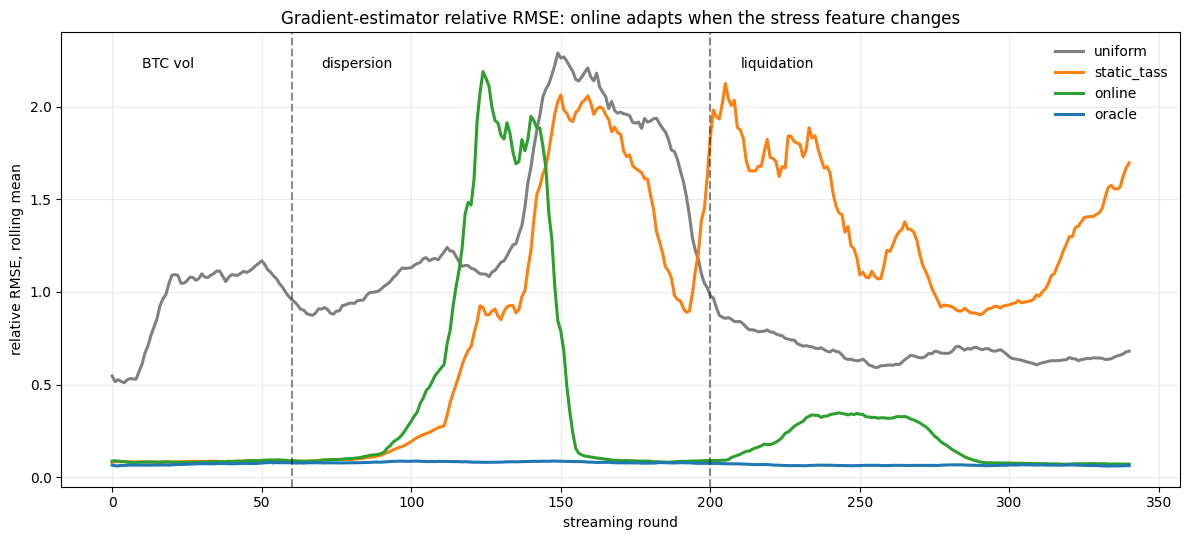

In [16]:
def add_epoch_lines(ax):
    for cut in [EPOCH_LEN - WINDOW, 2 * EPOCH_LEN - WINDOW]:
        if cut >= 0:
            ax.axvline(cut, color="black", linestyle="--", alpha=0.45)
    ax.text(10, ax.get_ylim()[1] * 0.92, "BTC vol", fontsize=10)
    ax.text(EPOCH_LEN - WINDOW + 10, ax.get_ylim()[1] * 0.92, "dispersion", fontsize=10)
    ax.text(2 * EPOCH_LEN - WINDOW + 10, ax.get_ylim()[1] * 0.92, "liquidation", fontsize=10)


plot_df = results.copy()
plot_df["rmse_smooth"] = (
    plot_df
    .sort_values("round")
    .groupby("method")["relative_rmse"]
    .transform(lambda s: s.rolling(12, min_periods=1).mean())
)

fig, ax = plt.subplots(figsize=(12, 5.5))
for method, color in [
    ("uniform", "gray"),
    ("static_tass", "tab:orange"),
    ("online", "tab:green"),
    ("oracle", "tab:blue"),
]:
    sub = plot_df[plot_df["method"] == method]
    ax.plot(sub["round"], sub["rmse_smooth"], label=method, lw=2.2, color=color)
ax.set_title("Gradient-estimator relative RMSE: online adapts when the stress feature changes")
ax.set_xlabel("streaming round")
ax.set_ylabel("relative RMSE, rolling mean")
add_epoch_lines(ax)
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(OUT_DIR / "rmse_over_time.png", dpi=180, bbox_inches="tight")
plt.show()

## 6. Sampling mass on the truly important blocks

Another way to see the mechanism: how much probability mass does each method put on the top 10% of blocks by true gradient norm in the current window?

If this number is high, the method is spending gradient budget where the action is.

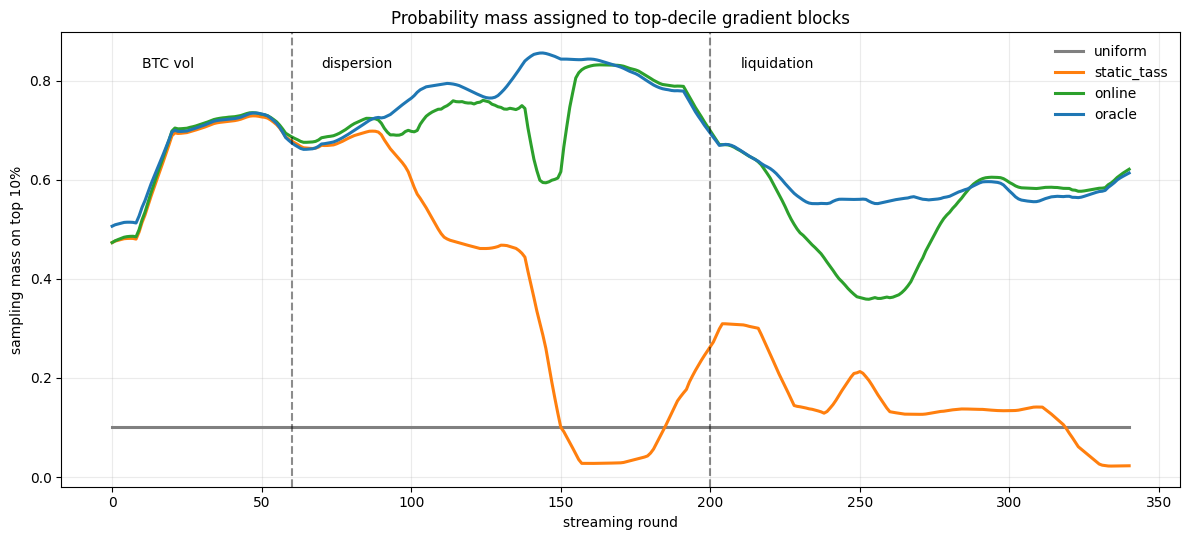

In [19]:
mass_df = results.copy()
mass_df["mass_smooth"] = (
    mass_df
    .sort_values("round")
    .groupby("method")["top_decile_mass"]
    .transform(lambda s: s.rolling(12, min_periods=1).mean())
)

fig, ax = plt.subplots(figsize=(12, 5.5))
for method, color in [
    ("uniform", "gray"),
    ("static_tass", "tab:orange"),
    ("online", "tab:green"),
    ("oracle", "tab:blue"),
]:
    sub = mass_df[mass_df["method"] == method]
    ax.plot(sub["round"], sub["mass_smooth"], label=method, lw=2.2, color=color)
ax.set_title("Probability mass assigned to top-decile gradient blocks")
ax.set_xlabel("streaming round")
ax.set_ylabel("sampling mass on top 10%")
add_epoch_lines(ax)
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(OUT_DIR / "top_decile_sampling_mass.png", dpi=180, bbox_inches="tight")
plt.show()

## 7. Learned online coefficients track the active stress feature

The online model is intentionally simple: discounted ridge regression on sampled feedback. Even so, its coefficients rotate toward the currently useful feature.

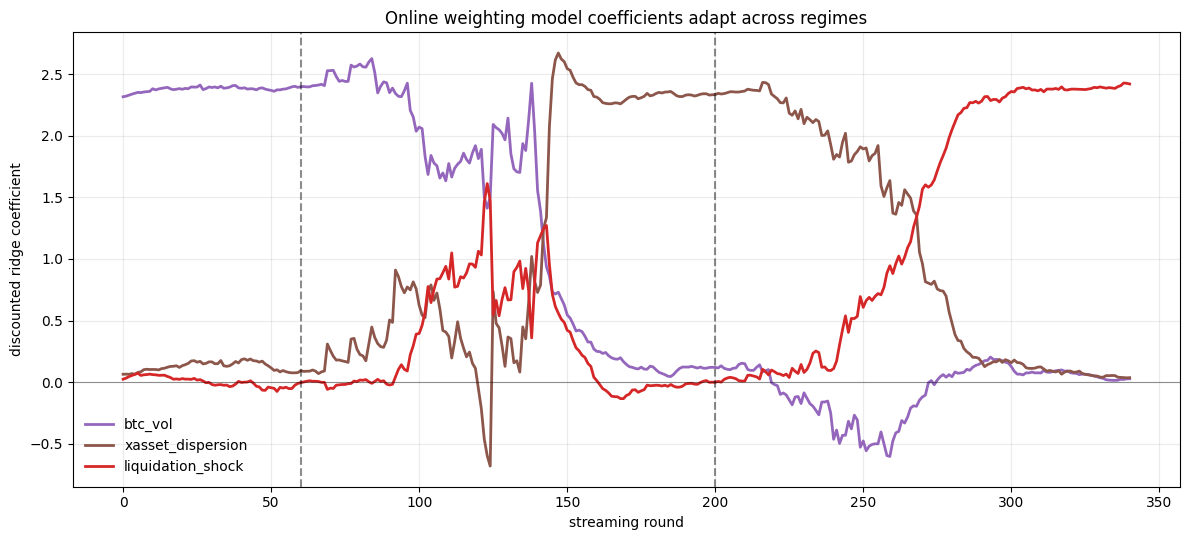

In [22]:
fig, ax = plt.subplots(figsize=(12, 5.5))
for name, color in [
    ("btc_vol", "tab:purple"),
    ("xasset_dispersion", "tab:brown"),
    ("liquidation_shock", "tab:red"),
]:
    ax.plot(coef_df["round"], coef_df[name], label=name, lw=2, color=color)
for cut in [EPOCH_LEN - WINDOW, 2 * EPOCH_LEN - WINDOW]:
    if cut >= 0:
        ax.axvline(cut, color="black", linestyle="--", alpha=0.45)
ax.axhline(0, color="black", lw=0.8, alpha=0.4)
ax.set_title("Online weighting model coefficients adapt across regimes")
ax.set_xlabel("streaming round")
ax.set_ylabel("discounted ridge coefficient")
ax.legend(frameon=False)
plt.tight_layout()
fig.savefig(OUT_DIR / "online_coefficients_over_time.png", dpi=180, bbox_inches="tight")
plt.show()

## 8. Summary table: where online wins

We summarize by epoch. The expected pattern:

- epoch 0: static and online are both good because static was trained here;
- epoch 1: static becomes stale, online adapts;
- epoch 2: static is very stale, online should be much closer to oracle.

In [25]:
summary = (
    results
    .groupby(["epoch", "method"], as_index=False)
    .agg(
        mean_relative_rmse=("relative_rmse", "mean"),
        median_relative_rmse=("relative_rmse", "median"),
        mean_top_decile_mass=("top_decile_mass", "mean"),
    )
)

wide_rmse = summary.pivot(index="epoch", columns="method", values="mean_relative_rmse")
wide_mass = summary.pivot(index="epoch", columns="method", values="mean_top_decile_mass")

display(summary.sort_values(["epoch", "mean_relative_rmse"]))

improvement_rows = []
for ep in sorted(results["epoch"].unique()):
    row = {"epoch": ep}
    vals = wide_rmse.loc[ep]
    row["online_vs_uniform_rmse_reduction_pct"] = 100 * (vals["uniform"] - vals["online"]) / vals["uniform"]
    row["online_vs_static_rmse_reduction_pct"] = 100 * (vals["static_tass"] - vals["online"]) / vals["static_tass"]
    row["online_oracle_gap_pct"] = 100 * (vals["online"] - vals["oracle"]) / vals["oracle"]
    improvement_rows.append(row)

improvement = pd.DataFrame(improvement_rows)
display(improvement)

# Also summarize the late part of each epoch, after the online model has had time to adapt.
late_results = results.copy()
late_results["epoch_start_block"] = late_results["epoch"] * EPOCH_LEN
late_results["within_epoch_block"] = late_results["end_block"] - late_results["epoch_start_block"]
late_results = late_results[late_results["within_epoch_block"] >= int(0.55 * EPOCH_LEN)]

late_summary = (
    late_results
    .groupby(["epoch", "method"], as_index=False)
    .agg(mean_relative_rmse=("relative_rmse", "mean"))
)
late_wide = late_summary.pivot(index="epoch", columns="method", values="mean_relative_rmse")

late_rows = []
for ep in sorted(late_wide.index):
    vals = late_wide.loc[ep]
    late_rows.append({
        "epoch": ep,
        "late_online_vs_uniform_rmse_reduction_pct": 100 * (vals["uniform"] - vals["online"]) / vals["uniform"],
        "late_online_vs_static_rmse_reduction_pct": 100 * (vals["static_tass"] - vals["online"]) / vals["static_tass"],
        "late_online_oracle_gap_pct": 100 * (vals["online"] - vals["oracle"]) / vals["oracle"],
    })

late_improvement = pd.DataFrame(late_rows)
display(late_improvement)

results.to_csv(OUT_DIR / "online_weighting_benchmark_results.csv", index=False)
coef_df.to_csv(OUT_DIR / "online_weighting_coefficients.csv", index=False)
summary.to_csv(OUT_DIR / "online_weighting_benchmark_summary.csv", index=False)
improvement.to_csv(OUT_DIR / "online_weighting_benchmark_improvement.csv", index=False)
late_improvement.to_csv(OUT_DIR / "online_weighting_benchmark_late_improvement.csv", index=False)

print("Saved benchmark outputs to", OUT_DIR.resolve())

,epoch,method,mean_relative_rmse,median_relative_rmse,mean_top_decile_mass
1,0,oracle,0.071357,0.070485,0.677469
2,0,static_tass,0.083797,0.082166,0.669582
0,0,online,0.084210,0.083488,0.677149
3,0,uniform,0.986676,1.015525,0.100000
5,1,oracle,0.080309,0.079814,0.773747
4,1,online,0.564513,0.116857,0.737631
6,1,static_tass,0.997265,0.892089,0.362621
7,1,uniform,1.430025,1.250471,0.100000
9,2,oracle,0.063984,0.063445,0.580308
8,2,online,0.177642,0.130670,0.530722


,epoch,online_vs_uniform_rmse_reduction_pct,online_vs_static_rmse_reduction_pct,online_oracle_gap_pct
0,0,91.465260,-0.493695,18.012218
1,1,60.524219,43.393846,602.926730
2,2,73.762629,86.572921,177.634510


,epoch,late_online_vs_uniform_rmse_reduction_pct,late_online_vs_static_rmse_reduction_pct,late_online_oracle_gap_pct
0,0,91.465260,-0.493695,18.012218
1,1,85.327267,84.271191,238.614385
2,2,88.430620,93.644054,19.487685


Saved benchmark outputs to /Users/diego/Stat 221/crypto_stage1_processed/online_weighting_epic_benchmark


## 9. Interpretation

This benchmark is intentionally designed for online weighting. That is the point.

The previous crypto HMM experiments asked the online weighting model to solve too many problems at once:

- posterior multimodality,
- label switching,
- weakly identified states,
- covariance geometry,
- finite-step SGLD bias,
- and gradient-estimator variance.

Here we isolate the last item. When gradient importance is heterogeneous, feature-predictable, and nonstationary, online weighting has a real reason to beat both uniform sampling and static TASS.

In market language: static TASS learns yesterday's volatility story; online weighting keeps listening to the tape.